# 8. Visualisation of Results

Visualisations are used to help interpret the Startup Viability Index (SVI) and its sub-indices.

The charts highlight:

- the distribution of SVI scores across countries,
- differences between high- and low-performing countries,
- variation across sub-index dimensions,
- and overall patterns within the dataset.

These visualisations make the results easier to understand and support interpretation of the composite index.

## 8.1. Distribution of Startup Viability Scores

A histogram is used to show the distribution of SVI scores across countries.

This helps identify the spread of scores and whether countries are grouped around certain levels of startup viability.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

svi_df = pd.read_csv("../data/results/startup_viability_index.csv")
sub_df = pd.read_csv("../data/results/subindex_scores.csv")

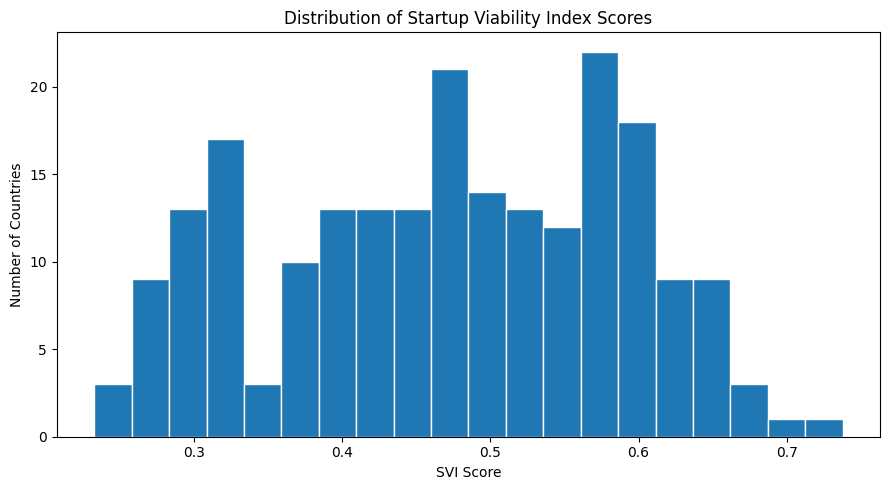

In [8]:
plt.figure(figsize=(9,5))

plt.hist(
    svi_df["Startup_Viability_Index"],
    bins=20,
    edgecolor="white",
    linewidth=1
)

plt.title("Distribution of Startup Viability Index Scores")
plt.xlabel("SVI Score")
plt.ylabel("Number of Countries")

plt.tight_layout()
plt.show()

The histogram shows that most countries are concentrated within the middle range of Startup Viability Index scores, while only a smaller number of countries achieve very high or very low values.

This suggests that startup viability is unevenly distributed globally, with relatively few countries operating at the highest levels of startup ecosystem performance.

## 8.2. Global Distribution of Startup Viability

A choropleth world map is used to show the geographical distribution of Startup Viability Index (SVI) scores across countries.

This helps identify regional patterns and differences in startup ecosystem strength around the world.

In [9]:
import plotly.express as px

fig = px.choropleth(
    svi_df,
    locations="Country Code",
    color="Startup_Viability_Index",
    hover_name="Country Name",
    color_continuous_scale="Viridis",
    title="Global Startup Viability Index (SVI)",
    projection="natural earth",
    hover_data={
        "Startup_Viability_Index":":.2f"
    }
)

fig.update_layout(
    title={
        "text": "Global Startup Viability Index (SVI)",
        "x": 0.5,
        "xanchor": "center"
    },
    width=1000,
    height=650,
    margin={"r":20, "t":60, "l":20, "b":20},
    coloraxis_colorbar=dict(
        title="SVI Score"
    )
)

fig.show()

The world map reveals clear regional differences in startup viability across countries.

Higher SVI scores are generally concentrated in North America, Western Europe, and parts of East Asia, while lower scores are more common in lower-income and politically unstable regions.

## 8.3 Startup Viability by Income Group

A boxplot is used to compare Startup Viability Index (SVI) scores across World Bank income groups.

This helps identify how startup ecosystem viability differs between low-income, middle-income, and high-income economies.

<Figure size 900x500 with 0 Axes>

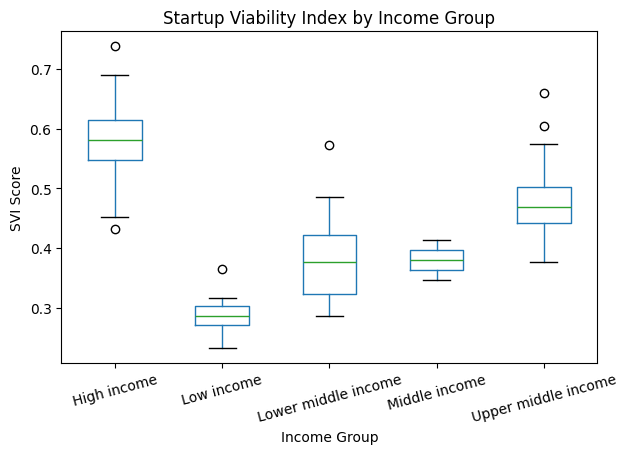

In [10]:
plt.figure(figsize=(9,5))

svi_df.boxplot(
    column="Startup_Viability_Index",
    by="Income Group",
    grid=False
)

plt.title("Startup Viability Index by Income Group")
plt.suptitle("")

plt.xlabel("Income Group")
plt.ylabel("SVI Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

The boxplot demonstrates that high-income economies generally achieve higher Startup Viability Index scores compared to middle-income and low-income countries.

In addition, lower-income groups show greater variability and lower median performance, indicating wider differences in startup ecosystem development.

## 8.4 Top Countries by Startup Viability Index

The following chart presents the ten highest-ranked countries according to the Startup Viability Index (SVI).

This visualisation highlights the countries with the strongest overall startup ecosystems based on the combined performance of the four sub-indices.

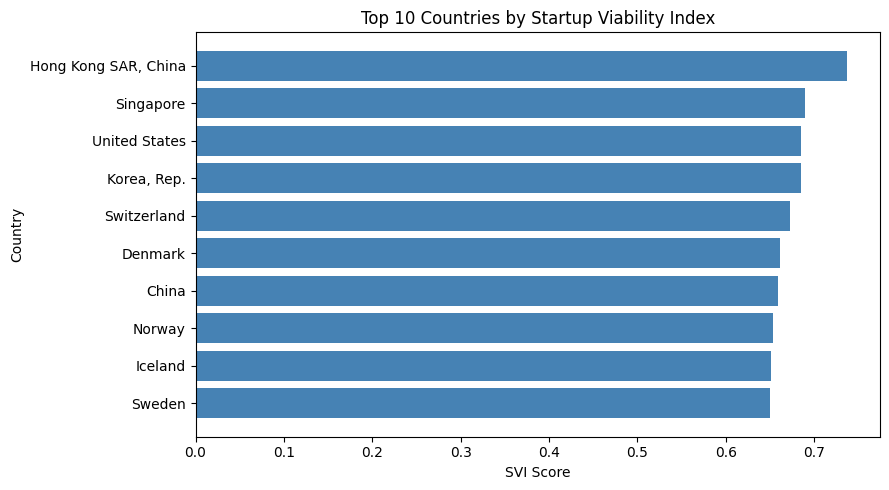

In [25]:
import matplotlib.pyplot as plt

top10 = df.sort_values(
    "Startup_Viability_Index",
    ascending=False
).head(10)

plt.figure(figsize=(9,5))

plt.barh(
    top10["Country Name"],
    top10["Startup_Viability_Index"],
    color="steelblue",
)

plt.gca().invert_yaxis()

plt.title("Top 10 Countries by Startup Viability Index")
plt.xlabel("SVI Score")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

The top-ranked countries consistently demonstrate strong overall performance across the different dimensions of startup viability.

These countries tend to combine economic stability, innovation capacity, financial strength, and skilled human capital to create highly supportive startup environments.

## 8.5 Sub-Index Comparison of Top Countries

The following chart compares the four sub-index dimensions across the highest-ranked countries in the Startup Viability Index.

This helps identify the areas where leading countries perform strongly and highlights differences in startup ecosystem structure.

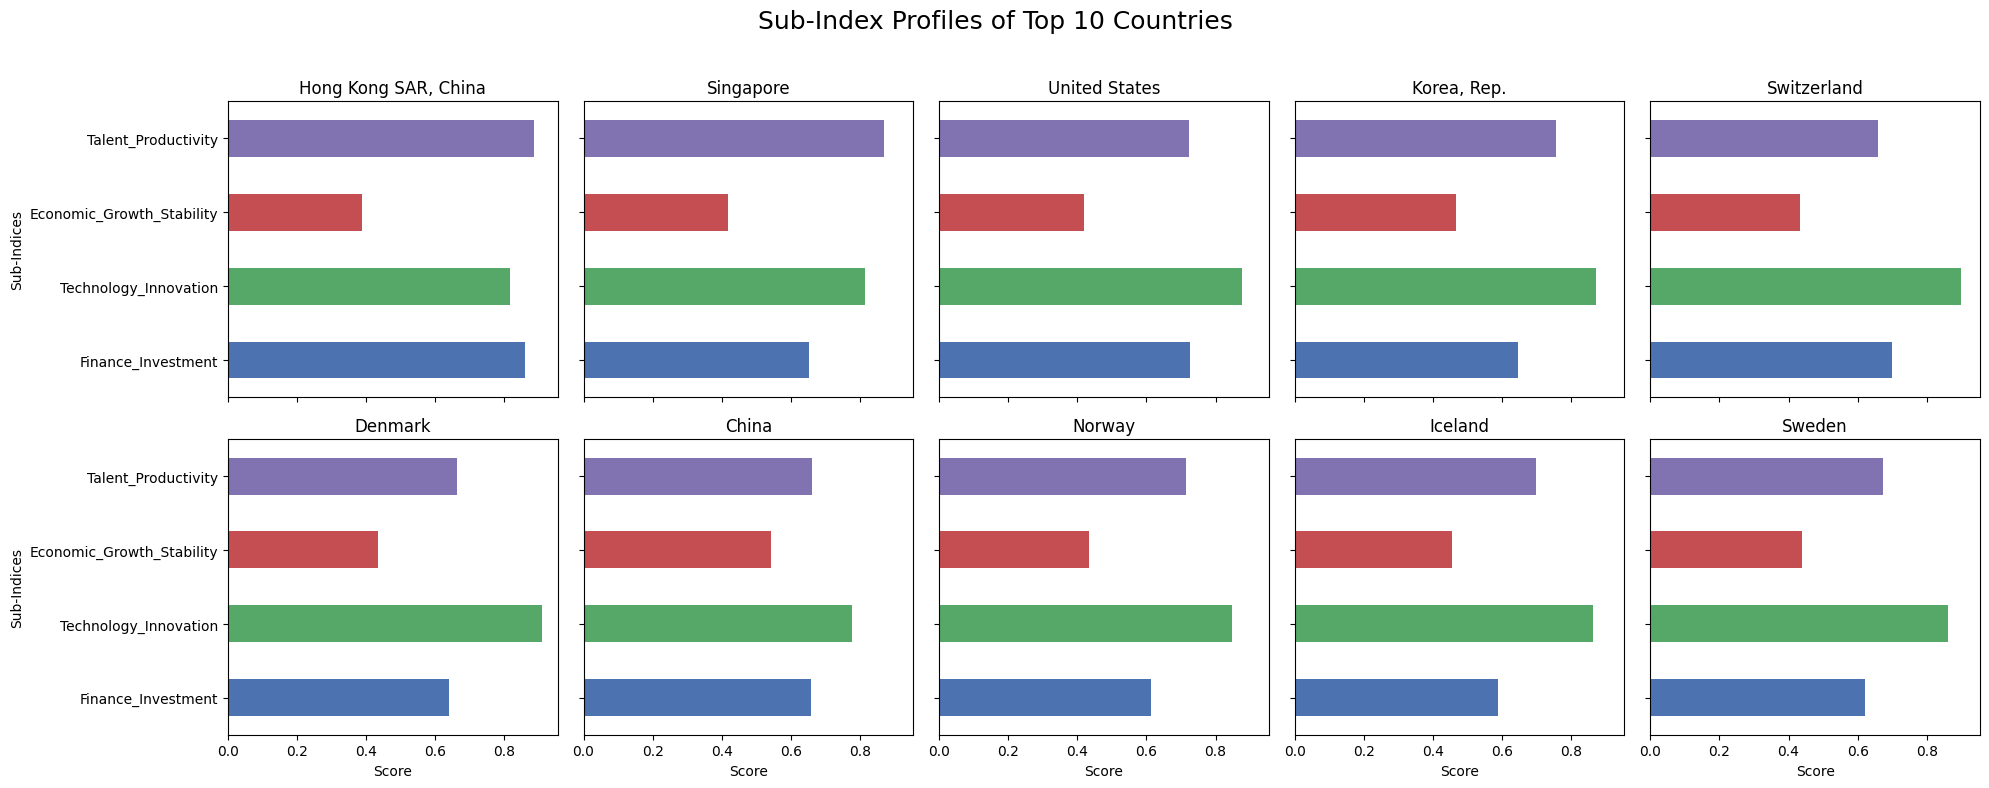

In [ ]:
# Get top 10 countries from SVI
top10_countries = (
    svi_df.sort_values(
        "Startup_Viability_Index",
        ascending=False
    )
    .head(10)["Country Name"]
)

# Filter sub-index dataset
top10_sub = sub_df[
    sub_df["Country Name"].isin(top10_countries)
]

# Keep ranking order
top10_sub = (
    top10_sub.set_index("Country Name")
    .loc[top10_countries]
)

# Sub-index columns
sub_cols = [
    "Finance_Investment",
    "Technology_Innovation",
    "Economic_Growth_Stability",
    "Talent_Productivity"
]

# Colors
colors = [
    "#4C72B0",
    "#55A868",
    "#C44E52",
    "#8172B2"
]

fig, axes = plt.subplots(2, 5, figsize=(20,8), sharex=True)

axes = axes.flatten()

for i, country in enumerate(top10_sub.index):

    scores = top10_sub.loc[country, sub_cols]

    scores.plot(
        kind="barh",
        ax=axes[i],
        color=colors
    )

    axes[i].set_title(country)
    axes[i].set_xlabel("Score")

    # Only keep y-labels for first chart in each row
    if i not in [0, 5]:
        axes[i].set_yticklabels([])
        axes[i].set_ylabel("")
    else:
        axes[i].set_ylabel("Sub-Indices")

# Main title
plt.suptitle(
    "Sub-Index Profiles of Top 10 Countries",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

The sub-index profiles show that leading countries generally perform well across all dimensions, and most countries demonstrate particular strengths in innovation, finance, or talent productivity.

This indicates that strong startup ecosystems can emerge through different combinations of structural advantages.

## 8.6 Sub-Index Comparison of Bottom Countries

The following chart compares the four sub-index dimensions across the lowest-ranked countries in the Startup Viability Index.

This helps identify the areas where leading countries perform weakly and highlights differences in startup ecosystem structure.

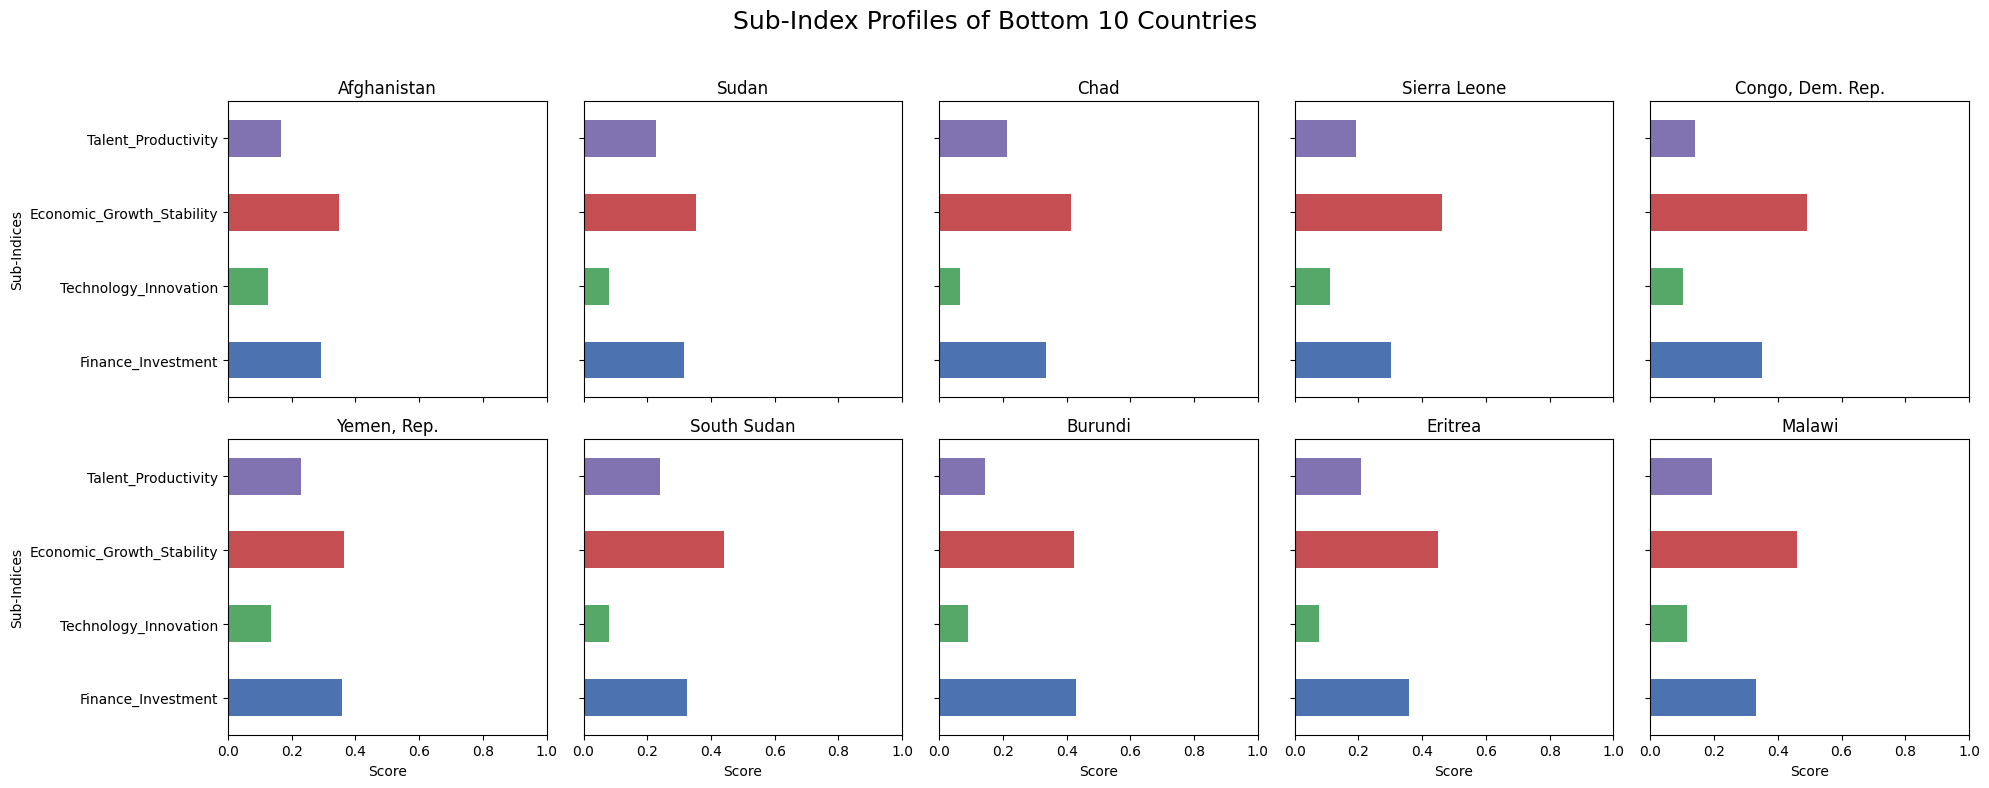

In [19]:
# Get bottom 10 countries from SVI
bottom10_countries = (
    svi_df.sort_values(
        "Startup_Viability_Index",
        ascending=True
    )
    .head(10)["Country Name"]
)

# Filter sub-index dataset
bottom10_sub = sub_df[
    sub_df["Country Name"].isin(bottom10_countries)
]

# Keep ranking order
bottom10_sub = (
    bottom10_sub.set_index("Country Name")
    .loc[bottom10_countries]
)

fig, axes = plt.subplots(2, 5, figsize=(20,8), sharex=True)

axes = axes.flatten()

for i, country in enumerate(bottom10_sub.index):

    scores = bottom10_sub.loc[country, sub_cols]

    scores.plot(
        kind="barh",
        ax=axes[i],
        color=colors
    )

    axes[i].set_title(country)
    axes[i].set_xlabel("Score")
    axes[i].set_xlim(0, 1)

    # Only keep y-labels for first chart in each row
    if i not in [0, 5]:
        axes[i].set_yticklabels([])
        axes[i].set_ylabel("")
    else:
        axes[i].set_ylabel("Sub-Indices")

# Main title
plt.suptitle(
    "Sub-Index Profiles of Bottom 10 Countries",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

The lowest-ranked countries generally record weak performance across multiple sub-index dimensions, particularly in innovation capacity and talent productivity.

These results suggest that limited institutional capacity and weaker economic conditions may constrain startup ecosystem development.

## 8.7 Summary

The visualisation techniques used throughout this section improved the interpretability of the Startup Viability Index and its underlying sub-indices.

The charts and maps highlighted global patterns, income-group differences, and the structural composition of high- and low-performing startup ecosystems.

Overall, the visualisations support the validity of the Startup Viability Index and provide a clearer understanding of startup viability across countries.